## Titanic
Vamos analisar os dados dos passageiros do Titanic. Começamos importando os dados de um arquivo csv ou carregando um dataset disponível no pacote Seaborn.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

Para termos um entendimento inicial do data frame utilizado, podemos utilizar o comando shape. Como o nome sugere, este comando nos informará o formato do dataframe em termos de linhas e colunas.

In [18]:
df.shape

(891, 15)

Para entendermos melhor o formato do data frame, podemos utilizar o comando head, que lista os 5 primeiros registros do data frame.

In [10]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


pclass: Passenger class (1 = 1st; 2 = 2nd; 3 = 3rd). \
sex: Sex of the passenger (male or female). \
age: Age of the passenger (float number). \
sibsp: Number of siblings/spouses aboard. \
parch: Number of parents/children aboard. \
fare: Passenger fare (in British pounds). \
embarked: Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton).

Dá pra saber também os tipos de dados de cada coluna com o comando dtypes.

In [15]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Outro ponto importante é entender que na maioria dos dataframes há dados incompletos. Para analisar quais dados estão imcompletos no nosso dataframe usaremos o comando isnull.

In [16]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Vamos agora usar um pouco de estatística descritiva para termos alguns insights a respeito das informações dos passageiros do Titanic. Vamos começar analisando a média, a mediana e a moda da idade dos passageiros.

In [ ]:
df['age'].mean()

In [7]:
df['age'].median()

np.float64(28.0)

In [8]:
df['age'].mode()

0    24.0
Name: age, dtype: float64

Vamos agora plotar histogramas das colunas nas quais é possível aplicar a geração automática de histogramas. A geração automática depende do tipo de dado da coluna.

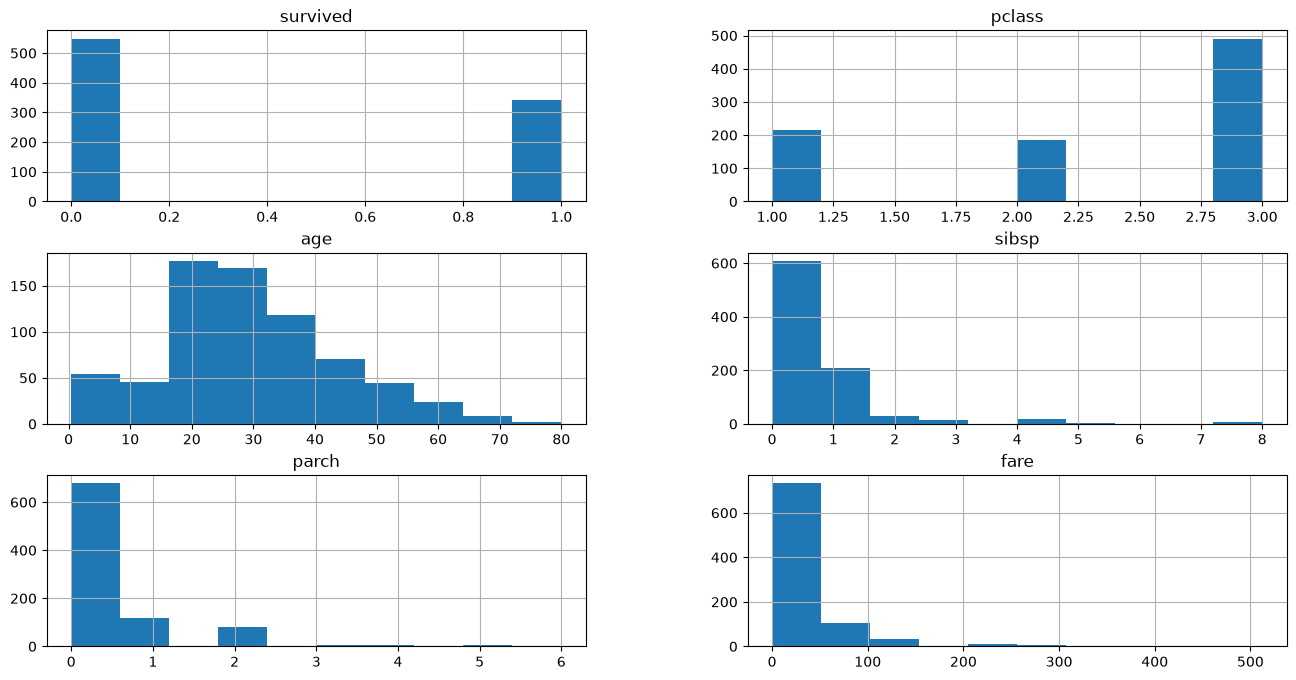

In [9]:
df.hist(figsize=(16,8));

Vamos agora plotar um histograma de uma coluna específica (Idade).

array([[<Axes: title={'center': 'age'}>]], dtype=object)

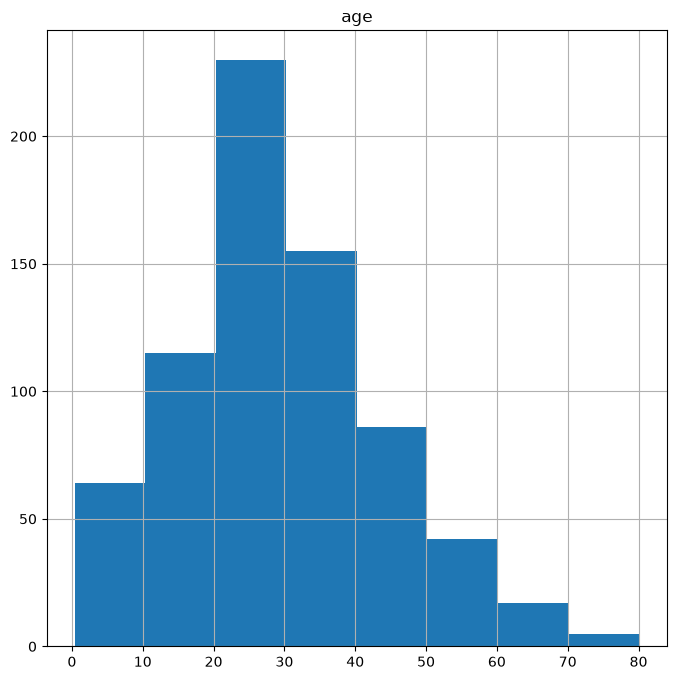

In [20]:
df.hist('age', bins=8,figsize=(8,8))

Agora vamos plotar um histograma da tarifa paga por cada passageiro.

array([[<Axes: title={'center': 'fare'}>]], dtype=object)

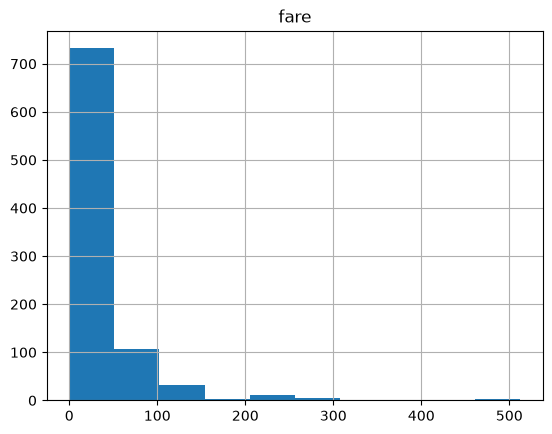

In [22]:
df.hist('fare')

Vamos analisar fatores que podem ter impactado a sobrevivência dos passageiros, começando pelo sexo. Vamos iniciar plotanto um gráfico que mostra o número de mortos e sobreviventes. 

<Axes: xlabel='alive', ylabel='count'>

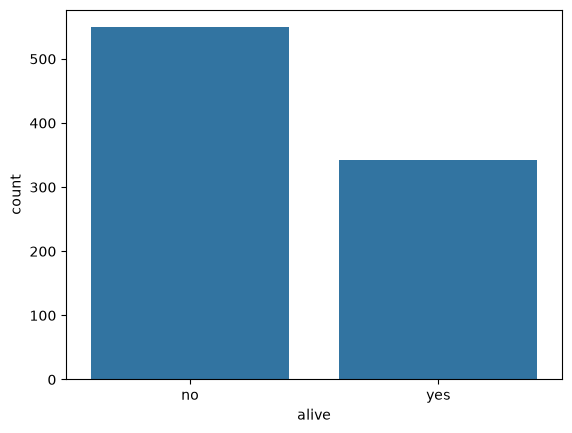

In [23]:
sns.countplot(x='alive',data=df)

Mulheres e homens morreram em igual proporção?

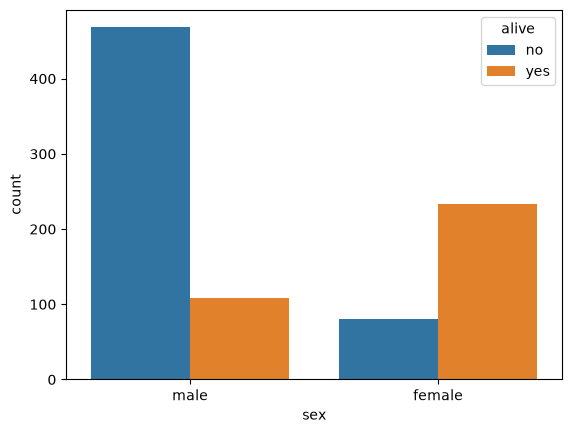

In [27]:
sns.countplot(x='sex', hue='alive', data=df);

A proporção de mortes foi igual em todas as classes do navio? (Primeira classe: mais cara; terceira classe: mais barata).

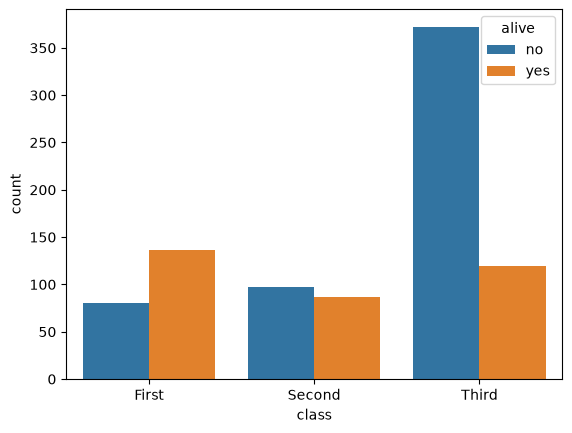

In [28]:
sns.countplot(x='class', hue='alive', data=df);

Gráficos de pizza são também interessantes para comparar proporções. Vamos plotar um gráfico de pizza para comparar o número total de sobreviventes vs não sobreviventes.

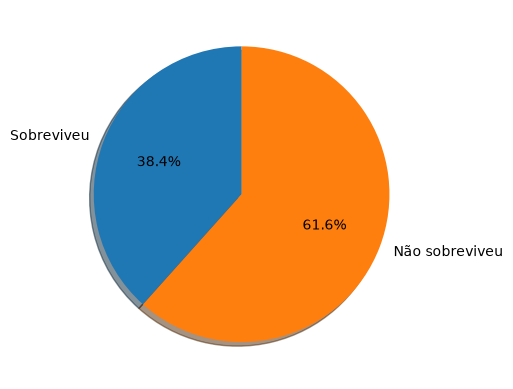

In [37]:
sobreviventes = df[df.survived == 1].count().iloc[0]
nao_sobreviventes = df[df.survived == 0].count().iloc[0]


plt.pie(
    [sobreviventes,nao_sobreviventes],
    labels=['Sobreviveu', 'Não sobreviveu'],
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
        );